# Finger EMG

## Load Data Session

### Load the CSV Files
`emg.csv`:
- timestamp, emg_channel_1, emg_channel_2, emg_channel_3, emg_channel_4, emg_channel_5, emg_channel_6, emg_channel_7, emg_channel_8

`fingers.csv`:
- timestamp, landmark_0_x, landmark_0_y, landmark_0_z, landmark_1_x, landmark_1_y, landmark_1_z, landmark_2_x, landmark_2_y, landmark_2_z, landmark_3_x, landmark_3_y, landmark_3_z, landmark_4_x, landmark_4_y, landmark_4_z, landmark_5_x, landmark_5_y, landmark_5_z, landmark_6_x, landmark_6_y, landmark_6_z, landmark_7_x, landmark_7_y, landmark_7_z, landmark_8_x, landmark_8_y, landmark_8_z, landmark_9_x, landmark_9_y, landmark_9_z, landmark_10_x, landmark_10_y, landmark_10_z, landmark_11_x, landmark_11_y, landmark_11_z, landmark_12_x, landmark_12_y, landmark_12_z, landmark_13_x, landmark_13_y, landmark_13_z, landmark_14_x, landmark_14_y, landmark_14_z, landmark_15_x, landmark_15_y, landmark_15_z, landmark_16_x, landmark_16_y, landmark_16_z, landmark_17_x, landmark_17_y, landmark_17_z, landmark_18_x, landmark_18_y, landmark_18_z, landmark_19_x, landmark_19_y, landmark_19_z, landmark_20_x, landmark_20_y, landmark_20_z

In [2]:
import os
import pandas as pd
from FingerDataProcess import FingerDataProcessor
from IPython.display import clear_output

def load_data(data_folder):
    """Loads EMG and finger angle data from a given session folder."""
    emg_path = os.path.join(data_folder, "emg.csv")
    finger_path = os.path.join(data_folder, "fingers.csv")
    emg_data = pd.read_csv(emg_path)
    
    processor = FingerDataProcessor()
    finger_angles = processor.load_and_process_csv(finger_path)
    
    # Change the timestamps to TimeDelta objects
    emg_data["timestamp"] = pd.to_timedelta(emg_data["timestamp"], unit="s")
    finger_angles["timestamp"] = pd.to_timedelta(finger_angles["timestamp"], unit="s")
    
    # Set the timestamps as the index
    emg_data.set_index("timestamp", inplace=True)
    finger_angles.set_index("timestamp", inplace=True)
    
    # Print the data folder and the number of rows with NaN values
    # print(data_folder)
    # emg_nan_rows = emg_data.isna().sum(axis=1).gt(0).sum()
    # emg_total_rows = len(emg_data)
    # print("EMG NaN rows:", emg_nan_rows, "({:.2f}%)".format(emg_nan_rows / emg_total_rows * 100))
    # finger_nan_rows = finger_angles.isna().sum(axis=1).gt(0).sum()
    # finger_total_rows = len(finger_angles)
    # print("Finger NaN rows:", finger_nan_rows, "({:.2f}%)".format(finger_nan_rows / finger_total_rows * 100))

    return emg_data, finger_angles

def load_session(session_folder):
    """Loads all sessions in a given data folder."""
    data_folders = [os.path.join(session_folder, folder) for folder in os.listdir(session_folder) if os.path.isdir(os.path.join(session_folder, folder))]
    session_data = [load_data(folder) for folder in data_folders]
    return session_data

ORIGINAL_EMG_FS = 250
ORIGINAL_FINGER_FS = 120

# Load all sessions in the data/ directory
data_folder = "../data_session_2"
session_data = load_session(data_folder)
# Clear the output Jupyter cell
clear_output()
# Print the number of loaded sessions
print("Loaded", len(session_data), "sessions.")

Loaded 20 sessions.


### Count the NaN values

In [3]:
# Print the percentage of NaN values in each session

# Calculate the percentage of NaN values in each session
nan_percentages = []
for emg_data, finger_data in session_data:
    emg_nan_rows = emg_data.isna().sum(axis=1).gt(0).sum()
    emg_total_rows = len(emg_data)
    emg_nan_percentage = emg_nan_rows / emg_total_rows * 100
    finger_nan_rows = finger_data.isna().sum(axis=1).gt(0).sum()
    finger_total_rows = len(finger_data)
    finger_nan_percentage = finger_nan_rows / finger_total_rows * 100
    nan_percentages.append((emg_nan_percentage, finger_nan_percentage))

total_emg_nan_percentage = sum(percentages[0] for percentages in nan_percentages) / len(nan_percentages)
total_finger_nan_percentage = sum(percentages[1] for percentages in nan_percentages) / len(nan_percentages)

# Print the results
print("Percentage of NaN values in each session:")
for i, percentages in enumerate(nan_percentages):
    print(f"Session {i + 1}: EMG {percentages[0]:.2f}%, Finger {percentages[1]:.2f}%")
print(f"Total: EMG {total_emg_nan_percentage:.2f}%, Finger {total_finger_nan_percentage:.2f}%")

Percentage of NaN values in each session:
Session 1: EMG 0.00%, Finger 34.78%
Session 2: EMG 0.00%, Finger 28.74%
Session 3: EMG 0.00%, Finger 4.05%
Session 4: EMG 0.00%, Finger 14.09%
Session 5: EMG 0.00%, Finger 16.36%
Session 6: EMG 0.00%, Finger 1.98%
Session 7: EMG 0.00%, Finger 20.47%
Session 8: EMG 0.00%, Finger 5.24%
Session 9: EMG 0.00%, Finger 2.91%
Session 10: EMG 0.00%, Finger 5.40%
Session 11: EMG 0.00%, Finger 17.09%
Session 12: EMG 0.00%, Finger 16.98%
Session 13: EMG 0.00%, Finger 16.43%
Session 14: EMG 0.00%, Finger 19.26%
Session 15: EMG 0.00%, Finger 12.31%
Session 16: EMG 0.00%, Finger 8.57%
Session 17: EMG 0.00%, Finger 9.86%
Session 18: EMG 0.00%, Finger 24.13%
Session 19: EMG 0.00%, Finger 13.28%
Session 20: EMG 0.00%, Finger 5.67%
Total: EMG 0.00%, Finger 13.88%


### Graph the Raw EMG Data

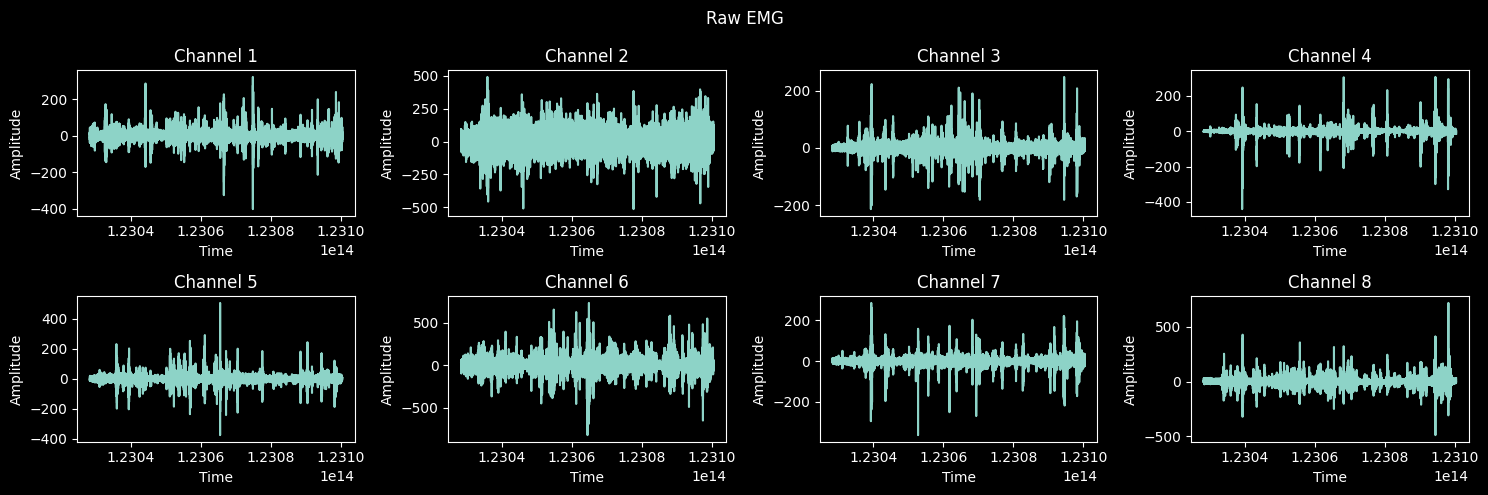

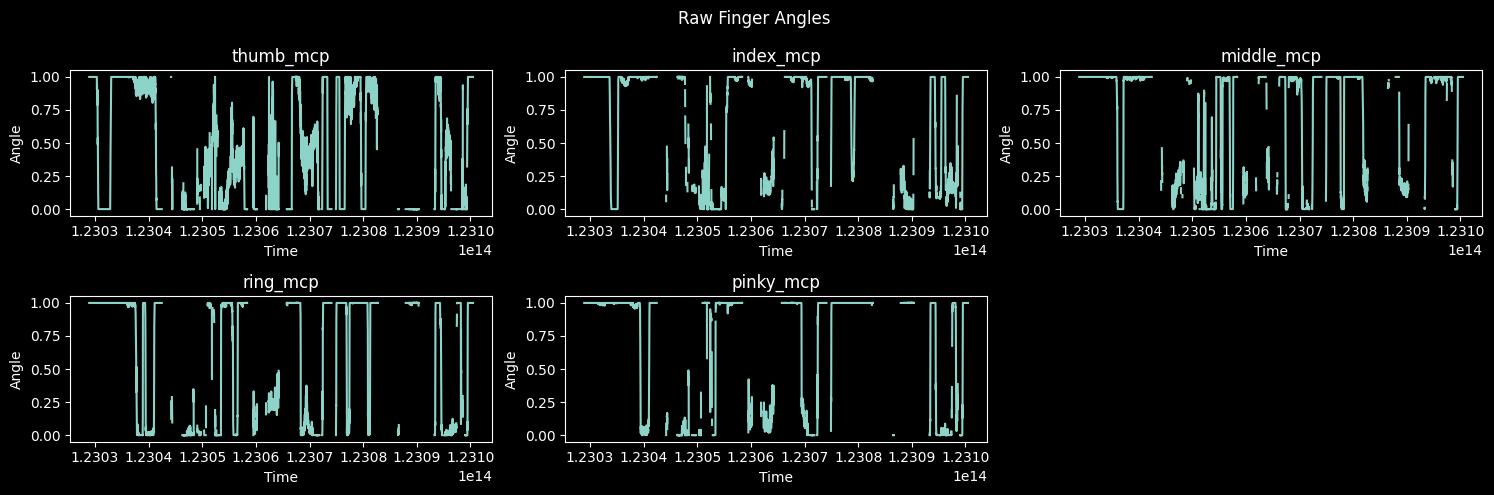

In [4]:
import matplotlib.pyplot as plt

def graph_emg_channel(emg_channel, title="EMG Channel"):
    """Graphs a single EMG channel."""
    plt.figure(figsize=(15, 5))
    plt.plot(emg_channel)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()
    
def graph_emg(emg_data, emg_columns=None, title="EMG"):
    """Graphs the EMG data for all channels in a 2x4 grid."""
    # If no columns are specified, use all columns except the timestamp
    if emg_columns is None:
        emg_columns = emg_data.columns
    
    # Plot a 2 x 4 grid of EMG data
    plt.figure(figsize=(15, 5))
    plt.suptitle(title)
    for i, channel_name in enumerate(emg_columns):
        plt.subplot(2, 4, i + 1)
        plt.plot(emg_data[channel_name], label=f"Channel {i + 1}")
        plt.title(f"Channel {i + 1}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def graph_finger(finger_data, finger_columns=None, title="Finger Angles"):
    """Graphs the finger angle data for all fingers in a 2x3 grid."""
    # If no columns are specified, use all columns except the timestamp
    if finger_columns is None:
        finger_columns = finger_data.columns
    
    # Plot a 2 x 3 grid of finger data
    plt.figure(figsize=(15, 5))
    plt.suptitle(title)
    for i, finger_name in enumerate(finger_columns):
        plt.subplot(2, 3, i + 1)
        plt.plot(finger_data[finger_name], label=f"{finger_name}")
        plt.title(f"{finger_name}")
        plt.xlabel("Time")
        plt.ylabel("Angle")
    plt.tight_layout()
    plt.show()

# Graph the first subsession
graph_emg(session_data[0][0], title="Raw EMG")
graph_finger(session_data[0][1], title="Raw Finger Angles")

## Preprocess Data

### Rectifying EMG Data, Low-Pass Filter, Resampling, and Handling Missing Data

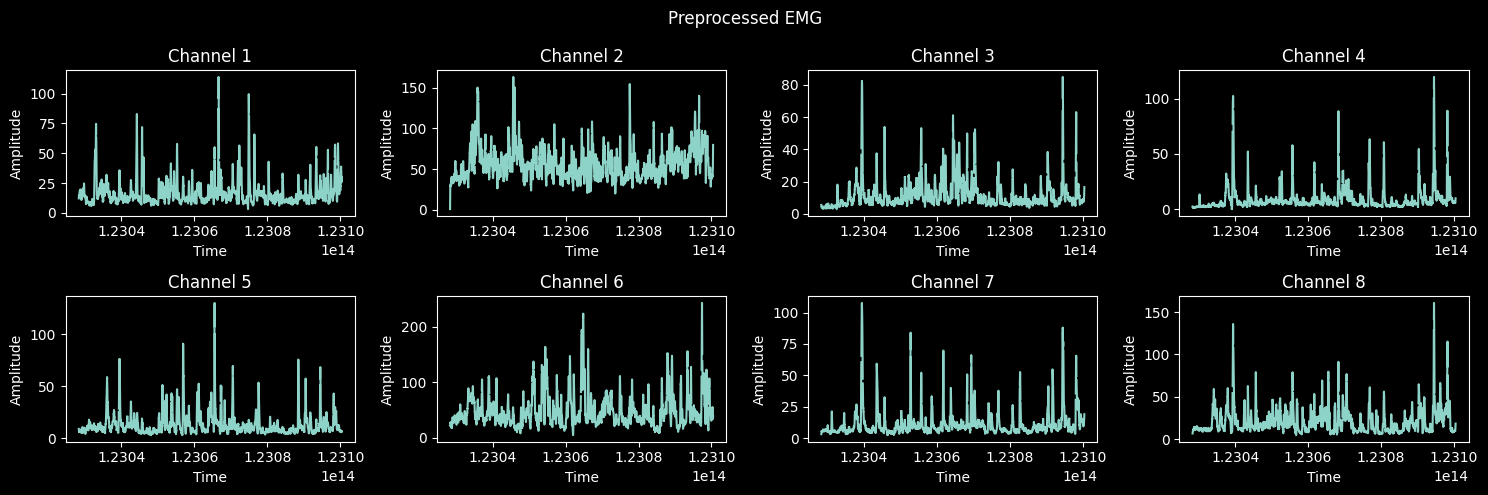

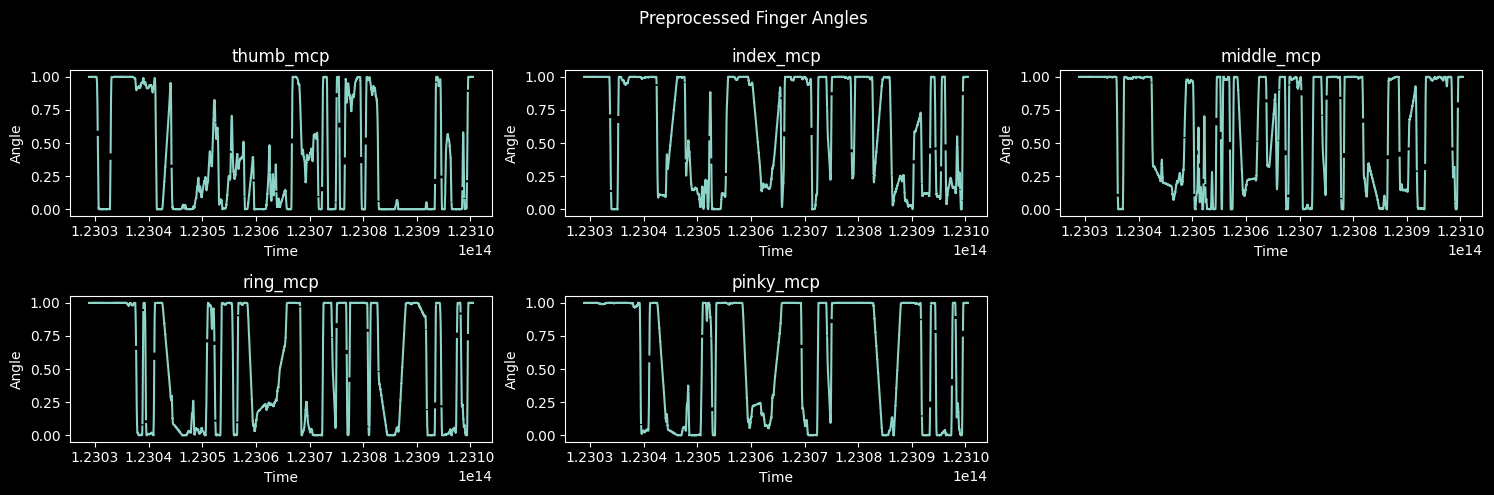

In [5]:
from scipy.signal import butter, filtfilt, resample
import matplotlib.pyplot as plt

def low_pass_filter(data, cutoff=4, fs=250, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def high_pass_filter(data, cutoff=20, fs=250, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

def preprocess_emg(emg_data, original_fs, new_fs=100, lp_cutoff=4):
    """Preprocesses the EMG data by filtering and resampling."""
    emg_data_filtered = emg_data.copy()
    # Rectify the EMG data
    emg_data_filtered = emg_data.abs()
    # Apply a low-pass filter to the EMG data
    for column in emg_data.columns:
        emg_data_filtered[column] = low_pass_filter(emg_data_filtered[column], cutoff=lp_cutoff, fs=original_fs)
    
    # Apply a high-pass filter to the EMG data
    # for column in emg_data.columns:
    #     emg_data_filtered[column] = high_pass_filter(emg_data_filtered[column], cutoff=10, fs=original_fs)
    
    # Resample the EMG data to the new sampling rate
    resampled_data = emg_data_filtered.resample(f"{int(1000 / new_fs)}ms").mean()
    
    return resampled_data
    
def moving_average(data, window_size=5):
    return data.rolling(window=window_size, min_periods=1).mean()

def preprocess_finger(finger_data, original_fs, new_fs=100, lp_cutoff=3, ma_window_size=5):
    """Preprocesses the finger angle data by filtering, smoothing, and resampling."""
    # Create NaN mask
    nan_mask = finger_data.isna()
    # Interpolate missing values
    finger_data = finger_data.interpolate()

    # Apply a low-pass filter to the finger angle data
    finger_data_filtered = finger_data.copy()
    for column in finger_data.columns:
        finger_data_filtered[column] = low_pass_filter(finger_data[column], cutoff=lp_cutoff, fs=original_fs)
    
    # Apply moving average smoothing
    finger_data_smoothed = finger_data_filtered.apply(lambda x: moving_average(x, window_size=ma_window_size))
    
    # Resample the finger angle data to the new sampling rate
    resampled_data = finger_data_smoothed.resample(f"{int(1000 / new_fs)}ms").mean()
    # resampled_nan_mask = nan_mask.resample(f"{int(1000 / new_fs)}ms").mean() > 0.5
    # resampled_data[resampled_nan_mask] = None
    
    # Clip the finger angle data to the valid range
    resampled_data = resampled_data.clip(0, 1)
    
    return resampled_data

def preprocess_session(session_data, new_fs=100):
    """Preprocesses the EMG and finger angle data for entire session."""
    session_data = session_data.copy()
    
    for i, (emg_data, finger_data) in enumerate(session_data):
        emg = preprocess_emg(emg_data, ORIGINAL_EMG_FS, new_fs)
        finger = preprocess_finger(finger_data, ORIGINAL_FINGER_FS, new_fs)
        
        session_data[i] = (emg, finger)
        
    return session_data

# Preprocess the session data
CURRENT_FS = 100
preprocessed_session_data = preprocess_session(session_data, new_fs=CURRENT_FS)

graph_emg(preprocessed_session_data[0][0], title="Preprocessed EMG")
graph_finger(preprocessed_session_data[0][1], title="Preprocessed Finger Angles")

### Normalize EMG Data

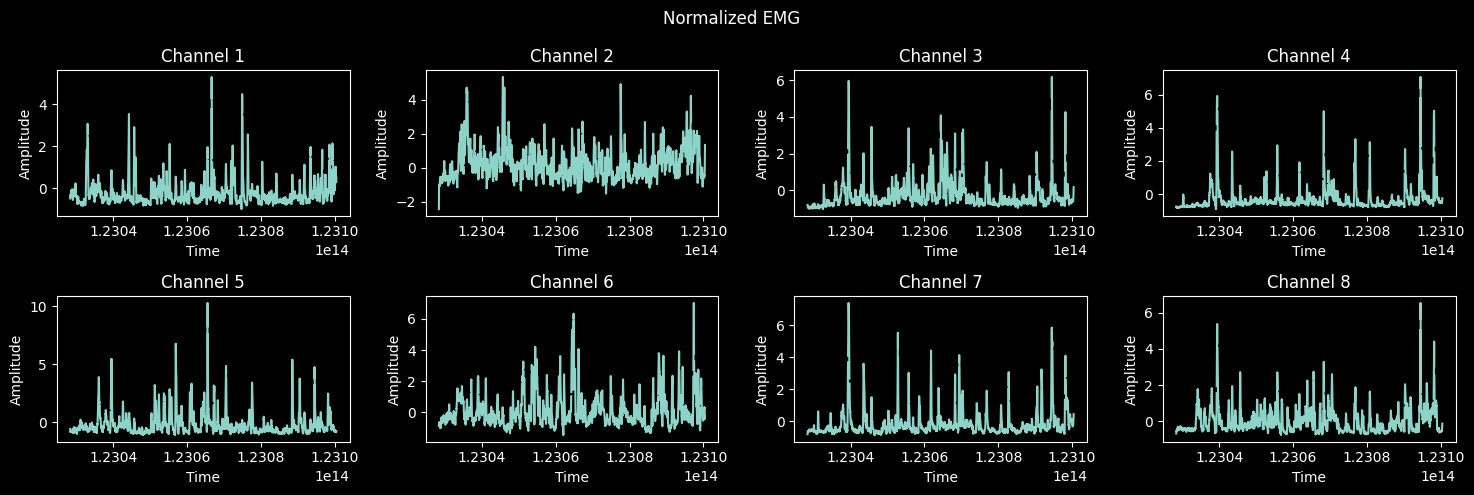

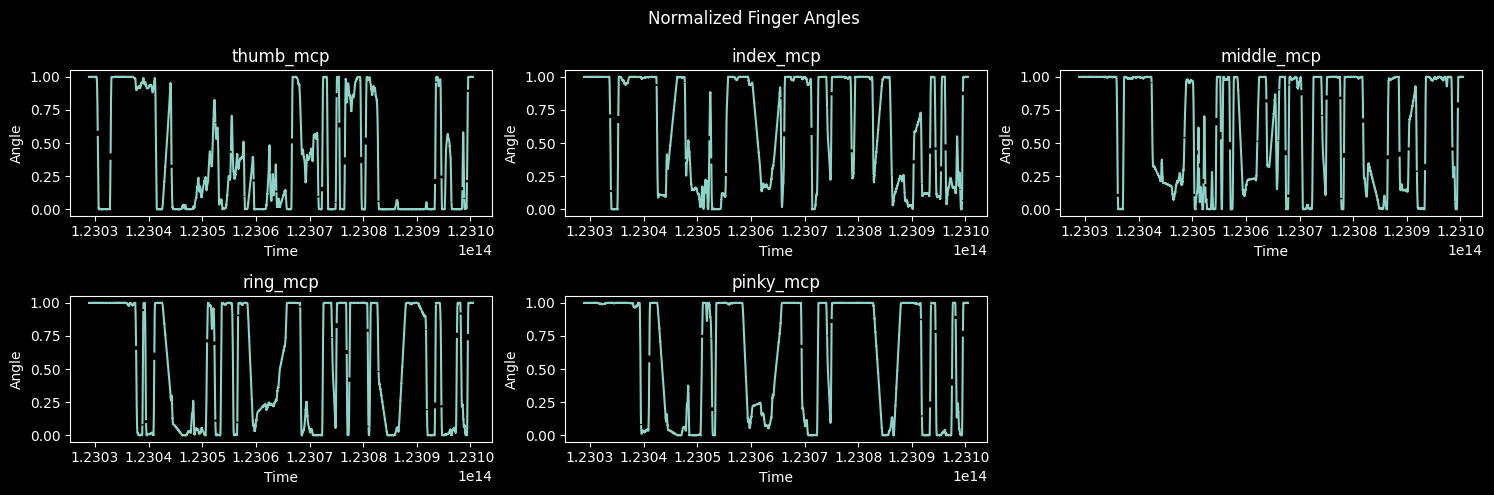

In [6]:
def calculate_session_mean_std(session_data):
    mean_sum = 0
    std_sum = 0
    
    for emg_data, _ in session_data:
        emg_mean = emg_data.mean()
        emg_std = emg_data.std()
        
        mean_sum += emg_mean
        std_sum += emg_std
        
    mean = mean_sum / len(session_data)
    std = std_sum / len(session_data)
    
    return mean, std
    
def normalize_session(session_data):
    mean, std = calculate_session_mean_std(session_data)
    normalized_session_data = []
    
    for emg_data, finger_data in session_data:
        normalized_emg_data = (emg_data - mean) / std
        normalized_session_data.append((normalized_emg_data, finger_data))
        
    return normalized_session_data, mean, std

normalized_session_data, mean, std = normalize_session(preprocessed_session_data)

graph_emg(normalized_session_data[0][0], title="Normalized EMG")
graph_finger(normalized_session_data[0][1], title="Normalized Finger Angles")

### Exponential Moving Average
Used for smoothing the EMG signal

In [7]:
def apply_ema(emg_data, span=10, order=1):
    """
    Applies Exponential Moving Average (EMA) to EMG data using Pandas' ewm.

    Parameters:
    - emg_data: pd.DataFrame or pd.Series
        The EMG data to smooth.
    - alpha: float
        The smoothing factor. Must be between 0 and 1.
    - order: int
        The number of times to apply the EMA.

    Returns:
    - pd.DataFrame or pd.Series
        The EMA-smoothed EMG data.
    """
    for _ in range(order):
        emg_data = emg_data.ewm(span=span, adjust=False).mean()
    return emg_data

def apply_ema_to_session(session_data, span_list=[50], order=2):
    """
    Applies Exponential Moving Average (EMA) to EMG data in a session.

    Parameters:
    - session_data: list of tuples
        The session data to smooth.
    - alpha: float
        The smoothing factor. Must be between 0 and 1.
    - order: int
        The number of times to apply the EMA.

    Returns:
    - list of tuples
        The EMA-smoothed session data.
    """
    smoothed_session_data = []
    for emg_data, finger_data in session_data:
        smooth_emg_list = []
        for span in span_list:
            smooth_emg_list.append(apply_ema(emg_data, span=span, order=order))
        
        merged_smooth_emg = pd.concat(smooth_emg_list, axis=1)
        smoothed_session_data.append((merged_smooth_emg, finger_data))

    return smoothed_session_data
    
# Apply EMA smoothing to the normalized session data
EMA_SPAN_LIST = [8, 16, 32, 64, 128]
EMA_ORDER = 2
smoothed_session_data = apply_ema_to_session(normalized_session_data, span_list=EMA_SPAN_LIST, order=EMA_ORDER)

### Align Data Streams

In [9]:
def align_data(session_data, emg_delay=0):
    extracted_data = []
    for emg_data, finger_data in session_data:
        # Shift the EMG data by the delay
        emg_data = emg_data.shift(periods=emg_delay)
        # Merge the EMG and finger angle data
        align_data = pd.merge_asof(emg_data, finger_data, direction="forward", on="timestamp")
        # Remove rows with NaN values
        align_data.dropna(inplace=True)
        # Set the timestamp as the index
        align_data.set_index("timestamp", inplace=True)
        extracted_data.append(align_data)
    
    return extracted_data

aligned_session_data = align_data(smoothed_session_data, emg_delay=0)  # Example delay of 50 ms
emg_channels = aligned_session_data[0].columns[:-5]
finger_channels = aligned_session_data[0].columns[-5:]

In [12]:
aligned_session_data[0].columns

Index(['emg_channel_1', 'emg_channel_2', 'emg_channel_3', 'emg_channel_4',
       'emg_channel_5', 'emg_channel_6', 'emg_channel_7', 'emg_channel_8',
       'emg_channel_1', 'emg_channel_2', 'emg_channel_3', 'emg_channel_4',
       'emg_channel_5', 'emg_channel_6', 'emg_channel_7', 'emg_channel_8',
       'emg_channel_1', 'emg_channel_2', 'emg_channel_3', 'emg_channel_4',
       'emg_channel_5', 'emg_channel_6', 'emg_channel_7', 'emg_channel_8',
       'emg_channel_1', 'emg_channel_2', 'emg_channel_3', 'emg_channel_4',
       'emg_channel_5', 'emg_channel_6', 'emg_channel_7', 'emg_channel_8',
       'emg_channel_1', 'emg_channel_2', 'emg_channel_3', 'emg_channel_4',
       'emg_channel_5', 'emg_channel_6', 'emg_channel_7', 'emg_channel_8',
       'thumb_mcp', 'index_mcp', 'middle_mcp', 'ring_mcp', 'pinky_mcp'],
      dtype='object')

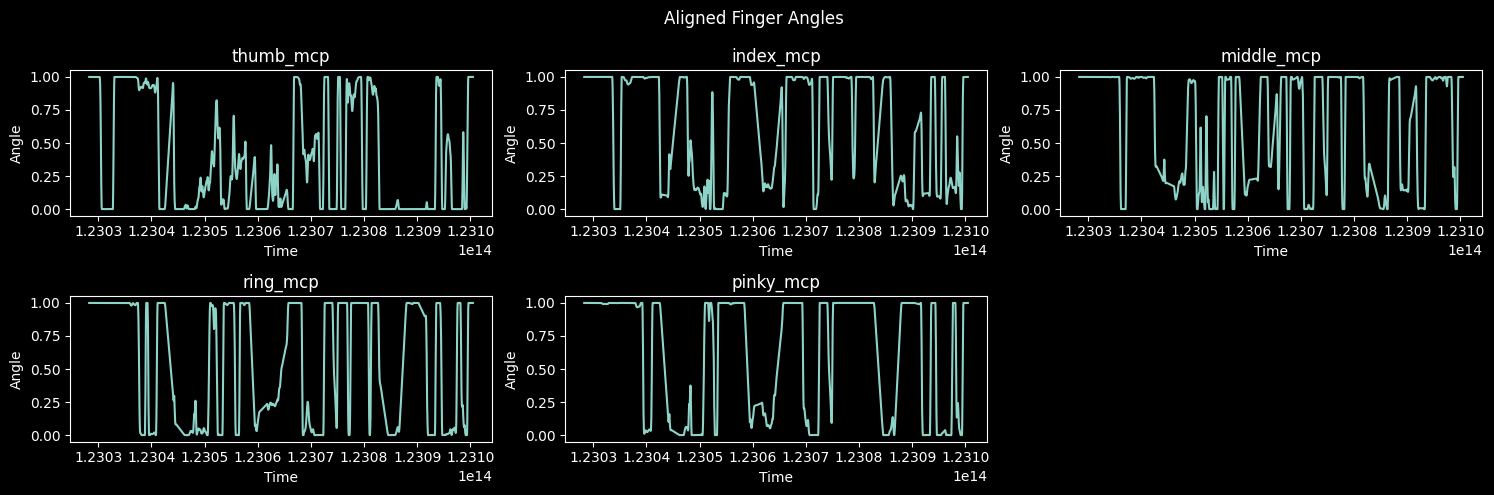

In [161]:
# graph_emg(aligned_session_data[0][emg_channels[0:7]], title="Aligned EMG")
graph_finger(aligned_session_data[0][finger_channels], title="Aligned Finger Angles")

### Train ML Model

In [13]:
# Create a linear regression model using keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GaussianNoise, Input

def create_model(input_shape, output_shape, gaussian_noise=0.1, loss='mean_squared_error'):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(gaussian_noise),
        # Dense(512, activation='relu'),
        # BatchNormalization(),
        # Dropout(0.3),
        # Dense(256, activation='relu'),
        # BatchNormalization(),
        # Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(output_shape, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['r2_score'])
    return model

def train_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=1024):
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_r2_score', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1, callbacks=[early_stopping])
    return history

def evaluate_model(model, X_test, y_test):
    loss = model.evaluate(X_test, y_test)
    return loss

# split data based on data sessions, use the 4 sessions with the already calculated 
# lowest nan_percentages (list) as test and validation data, and the rest as training data
def split_data(session_data, test_sessions, val_sessions):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []
    
    for i, df in enumerate(session_data):
        emg_data, finger_data = df[emg_channels], df[finger_channels]
        if i in test_sessions:
            X_test.append(emg_data)
            y_test.append(finger_data)
        elif i in val_sessions:
            X_val.append(emg_data)
            y_val.append(finger_data)
        else:
            X_train.append(emg_data)
            y_train.append(finger_data)
    
    X_train = pd.concat(X_train)
    y_train = pd.concat(y_train)
    X_val = pd.concat(X_val)
    y_val = pd.concat(y_val)
    X_test = pd.concat(X_test)
    y_test = pd.concat(y_test)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [14]:
# Find the 4 sessions with the lowest nan_percentages
sorted_nan_percentages = sorted(enumerate(nan_percentages), key=lambda x: x[1][0] + x[1][1])
test_sessions = [index for index, _ in sorted_nan_percentages[:2]]
val_sessions = [index for index, _ in sorted_nan_percentages[2:4]]

X_train, y_train, X_val, y_val, X_test, y_test = split_data(aligned_session_data, test_sessions, val_sessions)

# Train the model
input_shape = (X_train.shape[1],)
n_output = y_train.shape[1]
model = create_model(input_shape, n_output)
history = train_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=1024)

# Evaluate the model
loss, r2 = evaluate_model(model, X_test, y_test)
print("Test loss:", loss)
print("Test R^2 score:", r2)

Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1597 - r2_score: 0.0875 - val_loss: 0.0879 - val_r2_score: 0.4973
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0867 - r2_score: 0.5065 - val_loss: 0.0825 - val_r2_score: 0.5305
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0741 - r2_score: 0.5779 - val_loss: 0.0785 - val_r2_score: 0.5532
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0683 - r2_score: 0.6122 - val_loss: 0.0765 - val_r2_score: 0.5645
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0643 - r2_score: 0.6356 - val_loss: 0.0754 - val_r2_score: 0.5704
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0611 - r2_score: 0.6524 - val_loss: 0.0725 - val_r2_score: 0.5865
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0583 - r2_score: 0.6681 - val_loss: 0.0705 - val_r2_score: 0.5973
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0560 - r2_score: 0.6819 - 

In [15]:
from sklearn.metrics import r2_score
# Print the r_squared score for each finger
y_pred = model.predict(X_test)
finger_r2 = [r2_score(y_test.iloc[:, i], y_pred[:, i]) for i in range(y_test.shape[1])]

for i, r2 in enumerate(finger_r2):
    print(f"Test R^2 score for {finger_channels[i]}: {r2}")

380/380 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test R^2 score for thumb_mcp: -0.10770764211175599
Test R^2 score for index_mcp: 0.6769165502132547
Test R^2 score for middle_mcp: 0.746107821644366
Test R^2 score for ring_mcp: 0.7759557365752856
Test R^2 score for pinky_mcp: 0.34343427142836214


In [23]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, GaussianNoise, Input, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_finger_model(input_shape, gaussian_noise=0.1, loss='mse'):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(gaussian_noise),
        # Dense(128, activation='relu'),
        # BatchNormalization(),
        # Dropout(0.3),
        # Dense(64, activation='relu'),
        # BatchNormalization(),
        # Dropout(0.3),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss=loss, metrics=['r2_score'])
    return model

def create_and_train_finger_model(X_train, y_train, X_val, y_val, X_test, y_test, index, gaussian_noise=0.01, patience=5, epochs=10, batch_size=1024):
    # Create the model
    model = create_finger_model(input_shape=X_train.shape[1:], gaussian_noise=gaussian_noise)
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    
    # Train the model
    y_train = y_train.values[:, index] > 0.5
    y_val = y_val.values[:, index]
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_val, y_val), batch_size=batch_size, callbacks=[early_stopping], verbose=1)
    
    # Evaluate on the test set
    test_loss, test_r2 = model.evaluate(X_test, y_test.values[:, index], verbose=0)
    
    return model, history, test_loss, test_r2


thumb_model, thumb_history, thumb_test_loss, thumb_test_r2 = create_and_train_finger_model(X_train, y_train, X_val, y_val, X_test, y_test, 0)
index_model, index_history, index_test_loss, index_test_r2 = create_and_train_finger_model(X_train, y_train, X_val, y_val, X_test, y_test, 1)
middle_model, middle_history, middle_test_loss, middle_test_r2 = create_and_train_finger_model(X_train, y_train, X_val, y_val, X_test, y_test, 2)
ring_model, ring_history, ring_test_loss, ring_test_r2 = create_and_train_finger_model(X_train, y_train, X_val, y_val, X_test, y_test, 3)
pinky_model, pinky_history, pinky_test_loss, pinky_test_r2 = create_and_train_finger_model(X_train, y_train, X_val, y_val, X_test, y_test, 4)


Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1852 - r2_score: 0.2176 - val_loss: 0.1184 - val_r2_score: 0.3840
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1374 - r2_score: 0.4173 - val_loss: 0.1226 - val_r2_score: 0.3619
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1285 - r2_score: 0.4574 - val_loss: 0.1128 - val_r2_score: 0.4130
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1240 - r2_score: 0.4759 - val_loss: 0.1089 - val_r2_score: 0.4336
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1217 - r2_score: 0.4853 - val_loss: 0.1066 - val_r2_score: 0.4452
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1187 - r2_score: 0.4970 - val_loss: 0.1041 - val_r2_score: 0.4581
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1179 - r2_score: 0.5014 - val_loss: 0.1066 - val_r2_score: 0.4451
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1161 - r2_score: 0.5088 - val_loss: 0.10

In [24]:
from math import sqrt
# Print the test loss and R^2 for each finger model
print("Thumb Test Loss:", thumb_test_loss)
print("Thumb Test R^2:", thumb_test_r2)
print('Thumb Test R: ', sqrt(thumb_test_r2))
print("Index Test Loss:", index_test_loss)
print("Index Test R^2:", index_test_r2)
print('Index Test R: ', sqrt(index_test_r2))
print("Middle Test Loss:", middle_test_loss)
print("Middle Test R^2:", middle_test_r2)
print('Middle Test R: ', sqrt(middle_test_r2))
print("Ring Test Loss:", ring_test_loss)
print("Ring Test R^2:", ring_test_r2)
print('Ring Test R: ', sqrt(ring_test_r2))
print("Pinky Test Loss:", pinky_test_loss)
print("Pinky Test R^2:", pinky_test_r2)
print('Pinky Test R: ', sqrt(pinky_test_r2))

Thumb Test Loss: 0.1698373705148697
Thumb Test R^2: 0.024290919303894043
Thumb Test R:  0.1558554436132856
Index Test Loss: 0.0693855807185173
Index Test R^2: 0.5762928128242493
Index Test R:  0.7591395213162395
Middle Test Loss: 0.03913950175046921
Middle Test R^2: 0.7444223165512085
Middle Test R:  0.8627991171479075
Ring Test Loss: 0.051052823662757874
Ring Test R^2: 0.7129799127578735
Ring Test R:  0.8443813787370453
Pinky Test Loss: 0.07963661849498749
Pinky Test R^2: 0.4238303303718567
Pinky Test R:  0.6510225267775738
